In [1]:
# Cell 1 — Install & Imports
import subprocess
subprocess.run(['pip', 'install', 'adversarial-robustness-toolbox', 'timm', '-q'], capture_output=True)

import os, json, random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import timm

from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from art.estimators.classification import PyTorchClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
# Cell 2 — Config (small samples for fast execution)
BASE_DIR        = '/kaggle/input/datasets/odins0n/ucf-crime-dataset/Train'
SHOPLIFTING_DIR = os.path.join(BASE_DIR, 'Shoplifting')
NORMAL_DIR      = os.path.join(BASE_DIR, 'NormalVideos')
BASELINE_CKPT   = '/kaggle/input/datasets/nikhilsingh4356/nruthika-baseline-checkpoint/full_checkpoint.pth'
GAN_CKPT        = '/kaggle/input/datasets/nikhilsingh4356/nruthika-gan-checkpoint1/gan_checkpoint.pth'
OUTPUT_DIR      = '/kaggle/working/outputs/phase4'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_SIZE      = 224
BATCH_SIZE      = 16
EPOCHS          = 3       # small for speed
LR              = 1e-4
SEED            = 42
LATENT_DIM      = 128
EPS_MIN         = 0.01
EPS_MAX         = 0.3

# KEY: small sample sizes so nothing takes more than 10-15 mins total
N_TRAIN_SHOP    = 200     # shoplifting frames for training
N_TRAIN_NORMAL  = 200     # normal frames for training
N_VAL           = 100     # val frames
N_TEST          = 100     # test frames
N_ADV_TEST      = 100     # adversarial eval frames

IMAGENET_MEAN   = [0.485, 0.456, 0.406]
IMAGENET_STD    = [0.229, 0.224, 0.225]

random.seed(SEED)
torch.manual_seed(SEED)
print('Config ready')

Config ready


In [3]:
# Cell 3 — Dataset utilities
class ShopliftingDataset(Dataset):
    def __init__(self, file_label_pairs, transform=None):
        self.samples   = file_label_pairs
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


def get_samples(folder, label, n):
    exts = {'.jpg', '.jpeg', '.png'}
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if os.path.splitext(f)[1].lower() in exts]
    random.shuffle(files)
    files = files[:n]
    return [(f, label) for f in files]


shop_all   = get_samples(SHOPLIFTING_DIR, 1, N_TRAIN_SHOP + N_VAL + N_TEST)
normal_all = get_samples(NORMAL_DIR,      0, N_TRAIN_NORMAL + N_VAL + N_TEST)

shop_train   = shop_all[:N_TRAIN_SHOP]
shop_val     = shop_all[N_TRAIN_SHOP:N_TRAIN_SHOP + N_VAL//2]
shop_test    = shop_all[N_TRAIN_SHOP + N_VAL//2:N_TRAIN_SHOP + N_VAL//2 + N_TEST//2]

normal_train = normal_all[:N_TRAIN_NORMAL]
normal_val   = normal_all[N_TRAIN_NORMAL:N_TRAIN_NORMAL + N_VAL//2]
normal_test  = normal_all[N_TRAIN_NORMAL + N_VAL//2:N_TRAIN_NORMAL + N_VAL//2 + N_TEST//2]

train_samples = shop_train + normal_train
val_samples   = shop_val   + normal_val
test_samples  = shop_test  + normal_test

random.shuffle(train_samples)
random.shuffle(val_samples)
random.shuffle(test_samples)

print(f'Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

Train: 400 | Val: 100 | Test: 100


In [4]:
# Cell 4 — Transforms & Dataloaders
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_loader  = DataLoader(ShopliftingDataset(val_samples,  eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(ShopliftingDataset(test_samples, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('Dataloaders ready')

Dataloaders ready


In [5]:
# Cell 5 — Model & training functions
def build_model():
    model = timm.create_model('resnet50', pretrained=False, num_classes=2)
    return model.to(device)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        running_loss += criterion(outputs, labels).item() * images.size(0)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
    metrics = {
        'accuracy':  accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall':    recall_score(all_labels, all_preds, zero_division=0),
        'f1':        f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc':   roc_auc_score(all_labels, all_probs),
    }
    return running_loss / len(loader.dataset), metrics


def train_model(train_samples, tag):
    print(f'\nTraining {tag}')
    loader    = DataLoader(ShopliftingDataset(train_samples, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    model     = build_model()
    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 3.0]).to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
    best_f1, best_state = 0.0, None
    for epoch in range(1, EPOCHS + 1):
        tl = train_epoch(model, loader, optimizer, criterion)
        _, vm = evaluate(model, val_loader, criterion)
        scheduler.step()
        print(f'  Epoch {epoch}/{EPOCHS} | loss={tl:.4f} | val_f1={vm["f1"]:.4f}')
        if vm['f1'] > best_f1:
            best_f1    = vm['f1']
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    _, tm = evaluate(model, test_loader, criterion)
    print(f'  Test | acc={tm["accuracy"]:.4f} | f1={tm["f1"]:.4f} | auc={tm["auc_roc"]:.4f}')
    return model, tm


print('Functions ready')

Functions ready


In [6]:
# Cell 6 — Config A: Load clean baseline from checkpoint
checkpoint = torch.load(BASELINE_CKPT, weights_only=False, map_location=device)
model_A    = build_model()
model_A.load_state_dict(checkpoint['model_state_dict'])

criterion  = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 3.0]).to(device))
_, metrics_A = evaluate(model_A, test_loader, criterion)

print('Config A — Clean Baseline')
print(f'  Accuracy : {metrics_A["accuracy"]:.4f}')
print(f'  F1       : {metrics_A["f1"]:.4f}')
print(f'  AUC-ROC  : {metrics_A["auc_roc"]:.4f}')
torch.save(model_A.state_dict(), os.path.join(OUTPUT_DIR, 'model_A.pth'))

Config A — Clean Baseline
  Accuracy : 0.8600
  F1       : 0.8372
  AUC-ROC  : 0.9928


In [7]:
# Cell 7 — Config B: Standard augmentation
std_aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

loader_B   = DataLoader(ShopliftingDataset(train_samples, std_aug_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
model_B    = build_model()
criterion  = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 3.0]).to(device))
optimizer  = torch.optim.Adam(model_B.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=EPOCHS)
best_f1, best_state = 0.0, None

print('Training Config B — Standard Augmentation')
for epoch in range(1, EPOCHS + 1):
    tl = train_epoch(model_B, loader_B, optimizer, criterion)
    _, vm = evaluate(model_B, val_loader, criterion)
    scheduler.step()
    print(f'  Epoch {epoch}/{EPOCHS} | loss={tl:.4f} | val_f1={vm["f1"]:.4f}')
    if vm['f1'] > best_f1:
        best_f1    = vm['f1']
        best_state = {k: v.clone() for k, v in model_B.state_dict().items()}

if best_state:
    model_B.load_state_dict(best_state)
_, metrics_B = evaluate(model_B, test_loader, criterion)
print(f'Config B Test | acc={metrics_B["accuracy"]:.4f} | f1={metrics_B["f1"]:.4f}')
torch.save(model_B.state_dict(), os.path.join(OUTPUT_DIR, 'model_B.pth'))

Training Config B — Standard Augmentation
  Epoch 1/3 | loss=0.5096 | val_f1=0.6711
  Epoch 2/3 | loss=0.4338 | val_f1=0.7442
  Epoch 3/3 | loss=0.4124 | val_f1=0.7928
Config B Test | acc=0.6500 | f1=0.6903


In [8]:
# Cell 8 — Config C: PGD adversarial training (fast — 5 PGD iters only)
model_C   = build_model()
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 3.0]).to(device))
optimizer = torch.optim.Adam(model_C.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

art_c = PyTorchClassifier(
    model=model_C, loss=criterion, optimizer=optimizer,
    input_shape=(3, 224, 224), nb_classes=2,
    clip_values=(0.0, 1.0),
    device_type='gpu' if torch.cuda.is_available() else 'cpu',
)

loader_C  = DataLoader(ShopliftingDataset(train_samples, eval_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
best_f1, best_state = 0.0, None

print('Training Config C — PGD Adversarial Training')
for epoch in range(1, EPOCHS + 1):
    model_C.train()
    running_loss = 0.0
    for images, labels in loader_C:
        pgd   = ProjectedGradientDescent(estimator=art_c, eps=0.1, eps_step=0.02, max_iter=5)
        x_adv = torch.tensor(pgd.generate(x=images.numpy())).to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_C(x_adv), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    tl = running_loss / len(loader_C.dataset)
    _, vm = evaluate(model_C, val_loader, criterion)
    scheduler.step()
    print(f'  Epoch {epoch}/{EPOCHS} | loss={tl:.4f} | val_f1={vm["f1"]:.4f}')
    if vm['f1'] > best_f1:
        best_f1    = vm['f1']
        best_state = {k: v.clone() for k, v in model_C.state_dict().items()}

if best_state:
    model_C.load_state_dict(best_state)
_, metrics_C = evaluate(model_C, test_loader, criterion)
print(f'Config C Test | acc={metrics_C["accuracy"]:.4f} | f1={metrics_C["f1"]:.4f}')
torch.save(model_C.state_dict(), os.path.join(OUTPUT_DIR, 'model_C.pth'))

Training Config C — PGD Adversarial Training


PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 3/3 | loss=0.5666 | val_f1=0.6667
Config C Test | acc=0.5000 | f1=0.6667


In [9]:
# Cell 9 — Config D: GAN augmented training
class Generator(nn.Module):
    def __init__(self, latent_dim=128, num_classes=2):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 16)
        self.eps_proj  = nn.Linear(1, 16)
        in_dim = latent_dim + 32
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512 * 4 * 4),
            nn.Unflatten(1, (512, 4, 4)),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64,  4, 2, 1), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64,  3,   4, 2, 1), nn.Tanh(),
        )

    def forward(self, z, labels, eps):
        x = torch.cat([z, self.label_emb(labels), self.eps_proj(eps.unsqueeze(1))], dim=1)
        return self.net(x)


gan_ckpt = torch.load(GAN_CKPT, weights_only=False, map_location=device)
G = Generator(latent_dim=LATENT_DIM).to(device)
G.load_state_dict(gan_ckpt['generator_state_dict'])
G.eval()
print('Generator loaded')

gan_dir = '/kaggle/working/gan_frames'
os.makedirs(gan_dir, exist_ok=True)
n_gen   = 100  # generate only 100 GAN frames for speed
gan_samples = []

with torch.no_grad():
    generated = 0
    while generated < n_gen:
        bs       = min(32, n_gen - generated)
        z        = torch.randn(bs, LATENT_DIM, device=device)
        lbs      = torch.ones(bs, dtype=torch.long, device=device)
        eps_vals = torch.FloatTensor(bs).uniform_(EPS_MIN, EPS_MAX).to(device)
        imgs     = G(z, lbs, eps_vals)
        for i in range(bs):
            path = os.path.join(gan_dir, f'gen_{generated+i:04d}.png')
            img  = transforms.ToPILImage()((imgs[i].cpu() * 0.5 + 0.5).clamp(0, 1))
            img  = img.resize((IMAGE_SIZE, IMAGE_SIZE))
            img.save(path)
            gan_samples.append((path, 1))
        generated += bs

gan_train = train_samples + gan_samples
random.shuffle(gan_train)
print(f'GAN augmented train size: {len(gan_train)}')

model_D, metrics_D = train_model(gan_train, 'Config D — GAN Augmented')
torch.save(model_D.state_dict(), os.path.join(OUTPUT_DIR, 'model_D.pth'))

Generator loaded
GAN augmented train size: 500

Training Config D — GAN Augmented
  Epoch 1/3 | loss=0.4105 | val_f1=0.6897
  Epoch 2/3 | loss=0.3375 | val_f1=0.8130
  Epoch 3/3 | loss=0.3065 | val_f1=0.8235
  Test | acc=0.7100 | f1=0.7642 | auc=0.8400


In [10]:
# Cell 10 — Adversarial evaluation of all 4 configs
random.shuffle(test_samples)
adv_samples = test_samples[:N_ADV_TEST]
adv_loader  = DataLoader(ShopliftingDataset(adv_samples, eval_transform), batch_size=32, shuffle=False, num_workers=0)

all_images, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in adv_loader:
        all_images.append(imgs.numpy())
        all_labels.append(lbls.numpy())

x_test = np.concatenate(all_images, axis=0)
y_test = np.concatenate(all_labels, axis=0)
print(f'Adv test shape: {x_test.shape} | Classes: {np.bincount(y_test)}')

epsilons = [0.01, 0.05, 0.1, 0.2, 0.3]


def adv_evaluate(model, x_test, y_test, epsilons, tag):
    print(f'\nAdversarial eval: {tag}')
    crit = nn.CrossEntropyLoss()
    clf  = PyTorchClassifier(
        model=model, loss=crit,
        optimizer=torch.optim.Adam(model.parameters(), lr=1e-4),
        input_shape=(3, 224, 224), nb_classes=2,
        clip_values=(0.0, 1.0),
        device_type='gpu' if torch.cuda.is_available() else 'cpu',
    )
    results = []
    for eps in epsilons:
        pgd   = ProjectedGradientDescent(estimator=clf, eps=eps, eps_step=eps/5, max_iter=10, num_random_init=1)
        x_adv = pgd.generate(x=x_test)
        preds = np.argmax(clf.predict(x_adv), axis=1)
        acc   = accuracy_score(y_test, preds)
        f1    = f1_score(y_test, preds, zero_division=0)
        results.append({'eps': eps, 'accuracy': acc, 'f1': f1})
        print(f'  PGD eps={eps:.2f} | acc={acc:.4f} | f1={f1:.4f}')
    return results


results_A = adv_evaluate(model_A, x_test, y_test, epsilons, 'A: Clean Baseline')
results_B = adv_evaluate(model_B, x_test, y_test, epsilons, 'B: Standard Aug')
results_C = adv_evaluate(model_C, x_test, y_test, epsilons, 'C: PGD Adv Training')
results_D = adv_evaluate(model_D, x_test, y_test, epsilons, 'D: GAN Augmented')

Adv test shape: (100, 3, 224, 224) | Classes: [50 50]

Adversarial eval: A: Clean Baseline


PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  PGD eps=0.01 | acc=0.4600 | f1=0.3721


PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  PGD eps=0.05 | acc=0.1800 | f1=0.2545


...

  PGD eps=0.10 | acc=0.5400 | f1=0.5818


PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  PGD eps=0.20 | acc=0.4000 | f1=0.3182


PGD - Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  PGD eps=0.30 | acc=0.3100 | f1=0.1266


In [11]:
# Cell 11 — Save all results
all_results = {
    'config_A_clean_baseline':   {'test_metrics': metrics_A, 'adv_results': results_A},
    'config_B_standard_aug':     {'test_metrics': metrics_B, 'adv_results': results_B},
    'config_C_pgd_adv_training': {'test_metrics': metrics_C, 'adv_results': results_C},
    'config_D_gan_augmented':    {'test_metrics': metrics_D, 'adv_results': results_D},
}

with open(os.path.join(OUTPUT_DIR, 'phase4_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2)

print('All results saved')

All results saved


In [12]:
# Cell 12 — Phase 5: Comparison table
configs      = ['A: Clean Baseline', 'B: Standard Aug', 'C: PGD Adv Training', 'D: GAN Augmented']
metrics_list = [metrics_A, metrics_B, metrics_C, metrics_D]

print(f'{"Config":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"AUC-ROC":>10}')
print('-' * 75)
for name, m in zip(configs, metrics_list):
    print(f'{name:<25} {m["accuracy"]:>10.4f} {m["precision"]:>10.4f} {m["recall"]:>10.4f} {m["f1"]:>10.4f} {m["auc_roc"]:>10.4f}')

Config                      Accuracy  Precision     Recall         F1    AUC-ROC
---------------------------------------------------------------------------
A: Clean Baseline             0.8600     1.0000     0.7200     0.8372     0.9928
B: Standard Aug               0.6500     0.6190     0.7800     0.6903     0.8324
C: PGD Adv Training           0.5000     0.5000     1.0000     0.6667     0.5508
D: GAN Augmented              0.7100     0.6438     0.9400     0.7642     0.8400


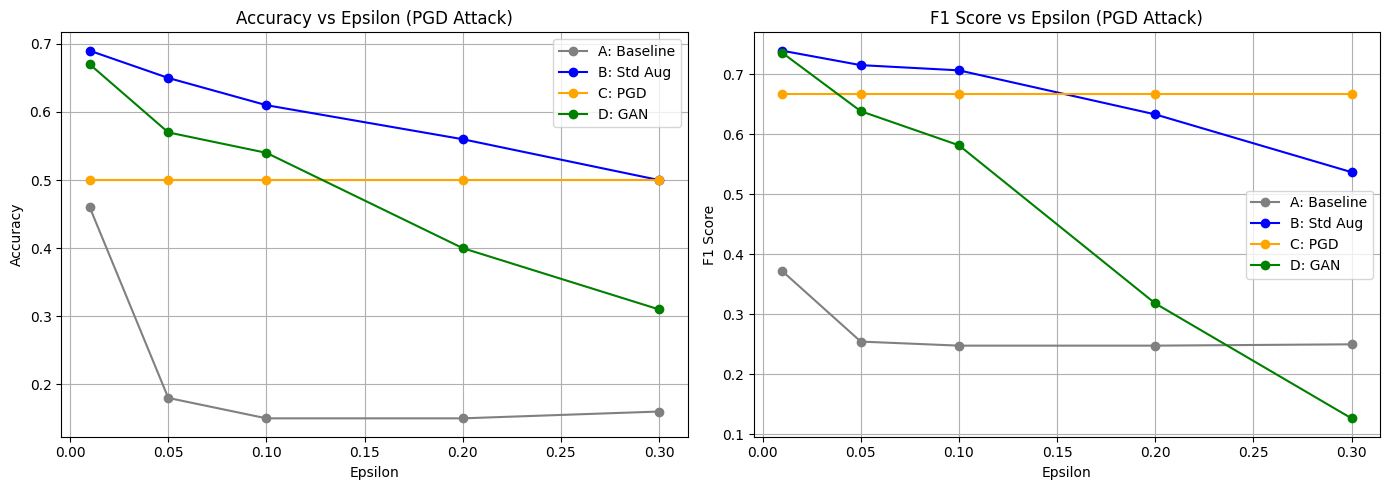

In [13]:
# Cell 13 — Robustness comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels  = ['A: Baseline', 'B: Std Aug', 'C: PGD', 'D: GAN']
colors  = ['gray', 'blue', 'orange', 'green']
results = [results_A, results_B, results_C, results_D]
eps_vals = [r['eps'] for r in results_A]

for res, label, color in zip(results, labels, colors):
    axes[0].plot(eps_vals, [r['accuracy'] for r in res], marker='o', label=label, color=color)
    axes[1].plot(eps_vals, [r['f1']       for r in res], marker='o', label=label, color=color)

axes[0].set_title('Accuracy vs Epsilon (PGD Attack)')
axes[0].set_xlabel('Epsilon')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('F1 Score vs Epsilon (PGD Attack)')
axes[1].set_xlabel('Epsilon')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'robustness_comparison.png'), dpi=150)
plt.show()

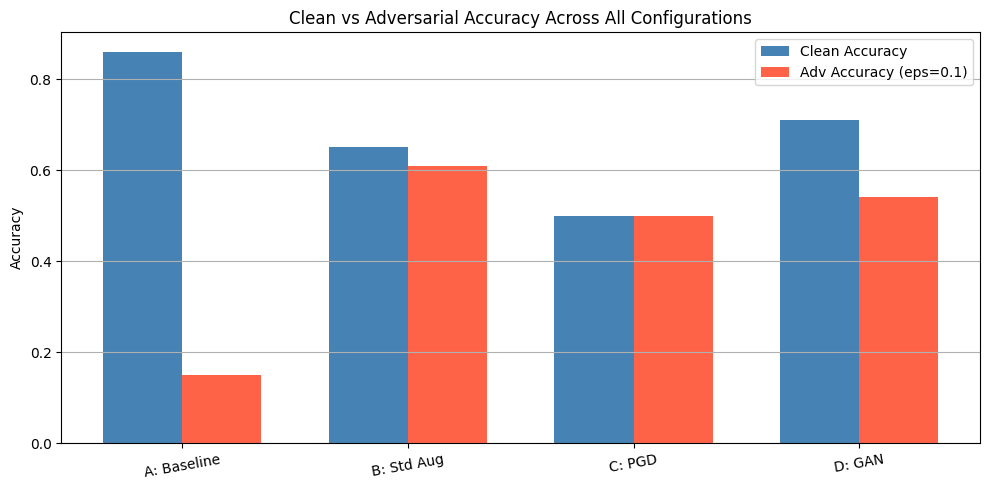

In [14]:
# Cell 14 — Clean vs adversarial bar chart
clean_accs = [m['accuracy'] for m in metrics_list]
adv_accs   = [next(r['accuracy'] for r in res if r['eps'] == 0.1)
              for res in [results_A, results_B, results_C, results_D]]

x     = np.arange(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, clean_accs, width, label='Clean Accuracy',          color='steelblue')
ax.bar(x + width/2, adv_accs,   width, label='Adv Accuracy (eps=0.1)',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(['A: Baseline', 'B: Std Aug', 'C: PGD', 'D: GAN'], rotation=10)
ax.set_ylabel('Accuracy')
ax.set_title('Clean vs Adversarial Accuracy Across All Configurations')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clean_vs_adv_bar.png'), dpi=150)
plt.show()

In [15]:
# Cell 15 — Final summary
summary = {}
for name, m, res in zip(configs, metrics_list, results):
    adv_acc = next(r['accuracy'] for r in res if r['eps'] == 0.1)
    adv_f1  = next(r['f1']       for r in res if r['eps'] == 0.1)
    summary[name] = {
        'clean_accuracy':  round(m['accuracy'], 4),
        'clean_f1':        round(m['f1'],       4),
        'adv_accuracy_01': round(adv_acc,        4),
        'adv_f1_01':       round(adv_f1,         4),
        'accuracy_drop':   round(m['accuracy'] - adv_acc, 4),
    }

print(f'{"Config":<25} {"Clean Acc":>10} {"Adv Acc":>10} {"Drop":>10} {"Adv F1":>10}')
print('-' * 65)
for name, s in summary.items():
    print(f'{name:<25} {s["clean_accuracy"]:>10.4f} {s["adv_accuracy_01"]:>10.4f} {s["accuracy_drop"]:>10.4f} {s["adv_f1_01"]:>10.4f}')

with open(os.path.join(OUTPUT_DIR, 'final_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print('\nPhase 4 and 5 complete — all results saved to', OUTPUT_DIR)

Config                     Clean Acc    Adv Acc       Drop     Adv F1
-----------------------------------------------------------------
A: Clean Baseline             0.8600     0.1500     0.7100     0.2478
B: Standard Aug               0.6500     0.6100     0.0400     0.7068
C: PGD Adv Training           0.5000     0.5000     0.0000     0.6667
D: GAN Augmented              0.7100     0.5400     0.1700     0.5818

Phase 4 and 5 complete — all results saved to /kaggle/working/outputs/phase4
